
[FIB 模式] Input image shape: (3775, 4096, 3)


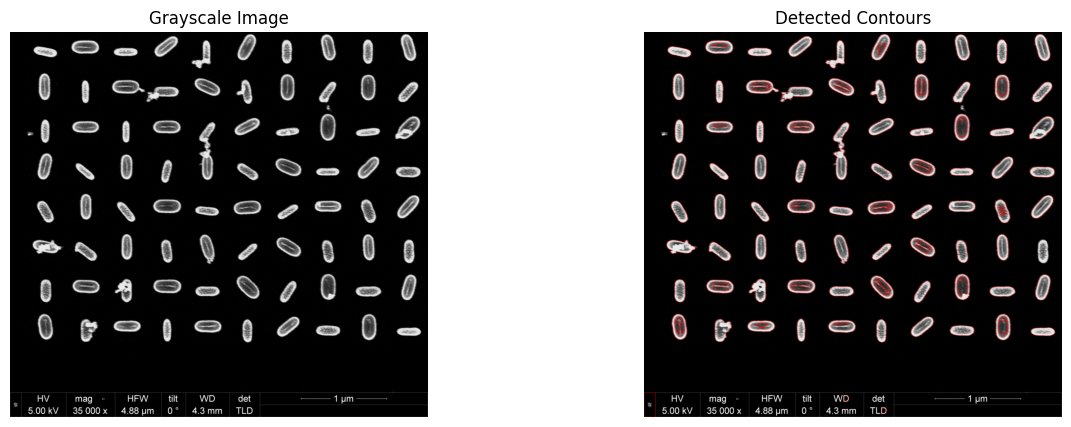

In [5]:
# %%
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from more_itertools import sort_together
import time
from tqdm import tqdm

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # 關閉 GPU
start = time.time()

# ================================================================
# 🔍 Find_Contours：通用輪廓偵測函式
# ================================================================
def Find_Contours(path_img, path_img_fib, mask_name, fib_name, resize,
                  thr_set, area_low, gaussian_blur, kernel_size,
                  mask_x_l, mask_x_r, mask_y_u, mask_y_d,
                  fib_x_l, fib_x_r, fib_y_u, fib_y_d,
                  mask_pad_x_l, mask_pad_x_r, mask_pad_y_u, mask_pad_d,
                  fib_pad_x_l, fib_pad_x_r, fib_pad_y_u, fib_pad_y_d,
                  mode, pad_mode):
    """
    根據 mode ('Mask' / 'FIB' / 'Mask+FIB') 偵測影像輪廓
    並回傳輪廓影像、灰階影像與偵測結果。
    """
    filter_edge = 20  # 用來過濾邊界雜訊

    # ================================================================
    # 🩸 模式 1：Mask 模式
    # ================================================================
    if mode == "Mask":
        img = cv2.imread(os.path.join(path_img, mask_name))
        if img is None:
            raise FileNotFoundError(f"無法讀取檔案：{os.path.join(path_img, mask_name)}")

        print("\n[Mask 模式] Input image shape:", img.shape)
        input_img = img.copy()

        # --- 裁切與 padding ---
        img_gray = img[mask_y_u:img.shape[0]-mask_y_d, mask_x_l:img.shape[1]-mask_x_r]
        if pad_mode == "on":
            img_gray = np.pad(img_gray, ((mask_pad_y_d, mask_pad_y_u), (mask_pad_x_r, mask_pad_x_l), (0,0)), 'constant')

        # --- 轉灰階 + Otsu 二值化 ---
        img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
        thr_auto, img_binary_auto = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr, binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # --- 找輪廓 ---
        contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
        img_final = cv2.drawContours(input_img.copy(), contours, -1, (0,0,255), 5)
        img_final_fib = np.zeros(img_final.shape, dtype=np.uint8)
        contours_fib = 0

        return img, img_gray, img_final, img_final_fib, contours, contours_fib

    # ================================================================
    # 🧠 模式 2：FIB 模式
    # ================================================================
    if mode == "FIB":
        img = cv2.imread(os.path.join(path_img_fib, fib_name))
        if img is None:
            raise FileNotFoundError(f"無法讀取檔案：{os.path.join(path_img_fib, fib_name)}")

        print("\n[FIB 模式] Input image shape:", img.shape)
        input_img = img.copy()

        # --- 灰階化 ---
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # --- 可選 Gaussian Blur ---
        if gaussian_blur == "on":
            img_gray = cv2.GaussianBlur(img_gray, kernel_size, 0)

        # --- 裁切與 padding ---
        img_gray = img_gray[fib_y_u:img_gray.shape[0]-fib_y_d, fib_x_l:img_gray.shape[1]-fib_x_r]
        if pad_mode == "on":
            img_gray = np.pad(img_gray, ((fib_pad_y_d,fib_pad_y_u),(fib_pad_x_r,fib_pad_x_l)), 'constant')

        # --- Otsu 閾值 + 手動偏移 ---
        thr_auto, img_binary_auto = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr, binary = cv2.threshold(img_gray, thr_auto + thr_set, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

        # --- 篩選輪廓 (依面積與邊界條件) ---
        img_binary_tmp = np.zeros(img_gray.shape, dtype=np.uint8)
        List_contours, List_cx, List_cy = [], [], []

        for c in contours:
            area = cv2.contourArea(c)
            if area >= area_low and area <= 50000:
                m = cv2.moments(c)
                if m["m00"] != 0:
                    cx = int(m["m10"] / m["m00"])
                    cy = int(m["m01"] / m["m00"])
                else:
                    cx, cy = -1, -1
                if (filter_edge <= cx <= img_gray.shape[1]-filter_edge) and (filter_edge <= cy <= img_gray.shape[0]-filter_edge):
                    List_contours.append(c)
                    List_cx.append(cx)
                    List_cy.append(cy)

        # --- 根據 x 排序 ---
        temp_cy = sort_together([List_cx, List_cy])[1]
        temp_contours = sort_together([List_cx, List_contours])[1]
        temp_cx = sorted(List_cx)
        temp_cx, temp_cy, temp_contours = temp_cx[:-2], temp_cy[:-2], temp_contours[:-2]

        # --- 填滿區域並畫出輪廓 ---
        img_final_fib = cv2.drawContours(img_binary_tmp, temp_contours, -1, (255,255,255), -1)
        img_final = cv2.drawContours(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR), temp_contours, -1, (0,0,255), 2)

        contours_fib = temp_contours
        return img, img_gray, img_final, img_final_fib, contours, contours_fib

    # ================================================================
    # 🧩 模式 3：Mask + FIB 同時處理
    # ================================================================
    if mode == "Mask+FIB":
        img = cv2.imread(os.path.join(path_img, mask_name))
        if img is None:
            raise FileNotFoundError(f"無法讀取檔案：{os.path.join(path_img, mask_name)}")

        # --- Mask 預處理 ---
        img = img[mask_y_u:img.shape[0]-mask_y_d, mask_x_l:img.shape[1]-mask_x_r]
        if pad_mode == "on":
            img = np.pad(img, ((mask_pad_y_d,mask_pad_y_u),(mask_pad_x_r,mask_pad_x_l),(0,0)), 'constant')
        input_img = img.copy()
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thr_auto, _ = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr, binary = cv2.threshold(img_gray, thr_auto + thr_set, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
        img_final = cv2.drawContours(input_img.copy(), contours, -1, (0,0,255), 10)

        # --- FIB 預處理 ---
        img_fib = cv2.imread(os.path.join(path_img_fib, fib_name))
        if img_fib is None:
            raise FileNotFoundError(f"無法讀取檔案：{os.path.join(path_img_fib, fib_name)}")

        img_gray_fib = cv2.cvtColor(img_fib, cv2.COLOR_BGR2GRAY)
        if pad_mode == "on":
            img_gray_fib = np.pad(img_gray_fib, ((fib_pad_y_d,fib_pad_y_u),(fib_pad_x_r,fib_pad_x_l)), 'constant')
        if gaussian_blur == "on":
            img_gray_fib = cv2.GaussianBlur(img_gray_fib, kernel_size, 0)

        img_gray_fib = img_gray_fib[fib_y_u:img_gray_fib.shape[0]-fib_y_d, fib_x_l:img_gray_fib.shape[1]-fib_x_r]
        thr_auto1, _ = cv2.threshold(img_gray_fib, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr1, binary1 = cv2.threshold(img_gray_fib, thr_auto1 + thr_set, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours1, _ = cv2.findContours(binary1, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

        img_final_fib = cv2.drawContours(np.zeros_like(img_gray_fib), contours1, -1, (255,255,255), -1)
        contours_fib = contours1

        return img, img_gray, img_final, img_final_fib, contours, contours_fib

# ================================================================
# ✅ 範例執行區 (Notebook 可直接運行)
# ================================================================
# 你可以修改下方的路徑與檔名
path_img = r"C:\Users\Lumos\Desktop\images"
path_img_fib = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI"
mask_name = "mask_example.png"
fib_name = "2nd_dep_barc6s.tif"

img, img_gray, img_final, img_final_fib, contours, contours_fib = Find_Contours(
    path_img=path_img,
    path_img_fib=path_img_fib,
    mask_name=mask_name,
    fib_name=fib_name,
    resize=None,
    thr_set=0,
    area_low=3000,
    gaussian_blur="on",
    kernel_size=(5,5),
    mask_x_l=0, mask_x_r=0, mask_y_u=0, mask_y_d=0,
    fib_x_l=0, fib_x_r=0, fib_y_u=0, fib_y_d=0,
    mask_pad_x_l=0, mask_pad_x_r=0, mask_pad_y_u=0, mask_pad_d=0,
    fib_pad_x_l=0, fib_pad_x_r=0, fib_pad_y_u=0, fib_pad_y_d=0,
    mode="FIB",        # 可改成 "FIB" 或 "Mask+FIB"
    pad_mode="off"
)

# 顯示結果
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB))
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title("Detected Contours")
plt.axis("off")
plt.show()


找到 309 個圖形

=== 測量結果 (μm) ===
圖形#1: 長軸=409.60 µm, 短軸=23.90 µm, 面積=9746.10 µm², 角度=0.0°
圖形#13: 長軸=8.35 µm, 短軸=24.64 µm, 面積=157.73 µm², 角度=90.6°
圖形#16: 長軸=10.34 µm, 短軸=24.55 µm, 面積=196.20 µm², 角度=91.1°
圖形#22: 長軸=11.38 µm, 短軸=27.62 µm, 面積=242.11 µm², 角度=90.2°
圖形#23: 長軸=12.70 µm, 短軸=27.42 µm, 面積=268.77 µm², 角度=91.2°
圖形#26: 長軸=9.87 µm, 短軸=24.00 µm, 面積=180.35 µm², 角度=178.9°
圖形#27: 長軸=15.25 µm, 短軸=23.30 µm, 面積=250.51 µm², 角度=16.7°
圖形#29: 長軸=8.15 µm, 短軸=23.91 µm, 面積=147.27 µm², 角度=178.7°
圖形#30: 長軸=11.58 µm, 短軸=27.14 µm, 面積=242.31 µm², 角度=51.4°
圖形#32: 長軸=14.69 µm, 短軸=27.04 µm, 面積=303.72 µm², 角度=179.8°
圖形#34: 長軸=14.10 µm, 短軸=26.23 µm, 面積=285.35 µm², 角度=171.5°
圖形#48: 長軸=10.45 µm, 短軸=25.69 µm, 面積=206.89 µm², 角度=89.9°
圖形#52: 長軸=10.18 µm, 短軸=24.96 µm, 面積=195.36 µm², 角度=90.4°
圖形#54: 長軸=9.45 µm, 短軸=25.37 µm, 面積=182.83 µm², 角度=33.2°
圖形#58: 長軸=13.52 µm, 短軸=27.55 µm, 面積=289.21 µm², 角度=93.6°
圖形#61: 長軸=14.09 µm, 短軸=28.50 µm, 面積=310.15 µm², 角度=91.3°
圖形#63: 長軸=10.94 µm, 短軸=24.51 µm, 面積=202.26 µm², 角度=179.2°


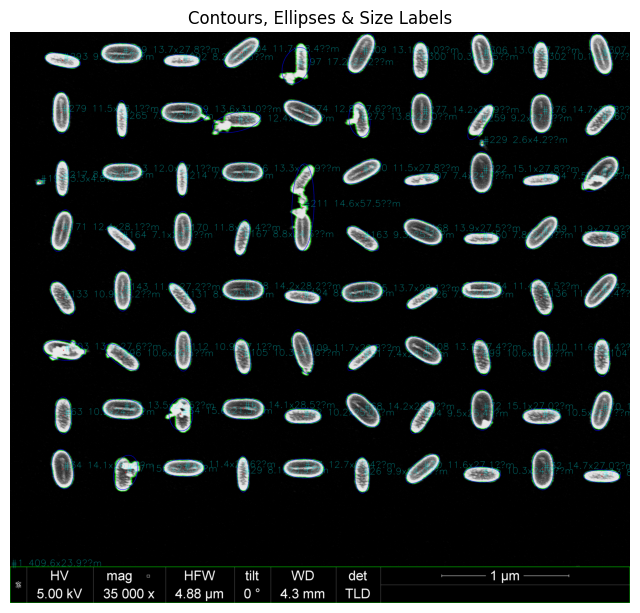

In [13]:
# %%
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# ================================================================
# 🧩 使用者設定
# ================================================================
path_img = r"c:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI"   # 改成你的資料夾
file_name = "2nd_dep_barc6s.tif"                 # 改成你的圖檔名稱
pixel_size = 0.1  # 單位：μm/pixel，可自行修改

# ================================================================
# 🖼️ 讀取影像並做前處理
# ================================================================
img = cv2.imread(os.path.join(path_img, file_name))
if img is None:
    raise FileNotFoundError("❌ 找不到指定影像，請確認路徑與檔名")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ================================================================
# 🔍 使用 cv2.findContours 找出輪廓
# ================================================================
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"找到 {len(contours)} 個圖形")

# ================================================================
# 📏 計算每個圖形的幾何資訊
# ================================================================
info_list = []
img_draw = img.copy()

for i, cnt in enumerate(contours):
    # 計算面積、外接矩形、橢圓擬合
    area_px = cv2.contourArea(cnt)
    if area_px < 10:  # 過小雜訊忽略
        continue
    area_um2 = area_px * (pixel_size**2)

    # 橢圓擬合 (需至少5個點)
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (major, minor), angle = ellipse
        major_um = major * pixel_size
        minor_um = minor * pixel_size
    else:
        x, y, w, h = cv2.boundingRect(cnt)
        major_um = max(w, h) * pixel_size
        minor_um = min(w, h) * pixel_size
        angle = 0

    info_list.append({
        "id": i+1,
        "center": (x, y),
        "major": major_um,
        "minor": minor_um,
        "angle": angle,
        "area_px": area_px,
        "area_um2": area_um2
    })

    # 畫輪廓與橢圓
    cv2.drawContours(img_draw, [cnt], -1, (0, 255, 0), 2)
    if len(cnt) >= 5:
        cv2.ellipse(img_draw, ellipse, (255, 0, 0), 2)
    # 標出中心與文字
    cv2.circle(img_draw, (int(x), int(y)), 3, (0, 0, 255), -1)
    text = f"#{i+1} {major_um:.1f}x{minor_um:.1f}µm"
    cv2.putText(img_draw, text, (int(x)+5, int(y)-5),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,0), 1, cv2.LINE_AA)

# ================================================================
# 🧾 列印尺寸資訊
# ================================================================
print("\n=== 測量結果 (μm) ===")
for obj in info_list:
    print(f"圖形#{obj['id']}: 長軸={obj['major']:.2f} µm, 短軸={obj['minor']:.2f} µm, 面積={obj['area_um2']:.2f} µm², 角度={obj['angle']:.1f}°")

# ================================================================
# 🎨 顯示結果
# ================================================================
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Contours, Ellipses & Size Labels")
plt.axis("off")
plt.show()


找到 309 個圖形

=== 測量結果 (μm) ===
圖形#1: 長軸=409.60 µm, 短軸=23.90 µm, 角度=0.0°
圖形#13: 長軸=8.35 µm, 短軸=24.64 µm, 角度=90.6°
圖形#16: 長軸=10.34 µm, 短軸=24.55 µm, 角度=91.1°
圖形#22: 長軸=11.38 µm, 短軸=27.62 µm, 角度=90.2°
圖形#23: 長軸=12.70 µm, 短軸=27.42 µm, 角度=91.2°
圖形#26: 長軸=9.87 µm, 短軸=24.00 µm, 角度=178.9°
圖形#27: 長軸=15.25 µm, 短軸=23.30 µm, 角度=16.7°
圖形#29: 長軸=8.15 µm, 短軸=23.91 µm, 角度=178.7°
圖形#30: 長軸=11.58 µm, 短軸=27.14 µm, 角度=51.4°
圖形#32: 長軸=14.69 µm, 短軸=27.04 µm, 角度=179.8°
圖形#34: 長軸=14.10 µm, 短軸=26.23 µm, 角度=171.5°
圖形#48: 長軸=10.45 µm, 短軸=25.69 µm, 角度=89.9°
圖形#52: 長軸=10.18 µm, 短軸=24.96 µm, 角度=90.4°
圖形#54: 長軸=9.45 µm, 短軸=25.37 µm, 角度=33.2°
圖形#58: 長軸=13.52 µm, 短軸=27.55 µm, 角度=93.6°
圖形#61: 長軸=14.09 µm, 短軸=28.50 µm, 角度=91.3°
圖形#63: 長軸=10.94 µm, 短軸=24.51 µm, 角度=179.2°
圖形#64: 長軸=15.63 µm, 短軸=21.52 µm, 角度=175.6°
圖形#68: 長軸=14.20 µm, 短軸=27.96 µm, 角度=134.9°
圖形#70: 長軸=12.71 µm, 短軸=27.33 µm, 角度=14.7°
圖形#72: 長軸=15.08 µm, 短軸=27.05 µm, 角度=178.9°
圖形#91: 長軸=7.42 µm, 短軸=24.81 µm, 角度=49.9°
圖形#96: 長軸=10.63 µm, 短軸=26.47 µm, 角度=123.8°
圖

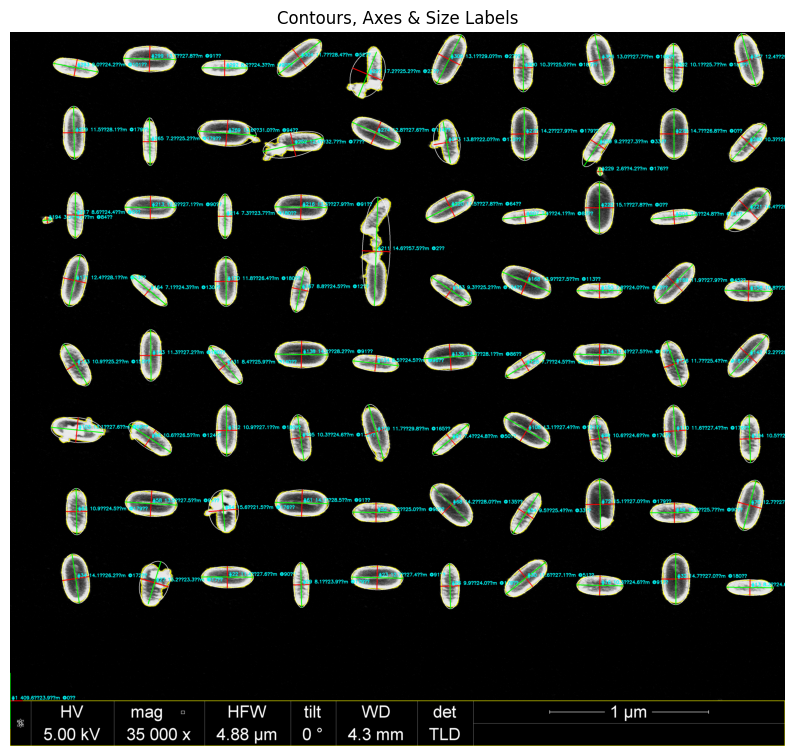

In [14]:
# %%
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# ================================================================
# 🧩 使用者設定
# ================================================================
path_img = r"c:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI"   # 改成你的資料夾
file_name = "2nd_dep_barc6s.tif"                      # 改成你的圖檔名稱
pixel_size = 0.1  # 單位：μm/pixel，可自行修改

# ================================================================
# 🖼️ 讀取影像並做前處理
# ================================================================
img = cv2.imread(os.path.join(path_img, file_name))
if img is None:
    raise FileNotFoundError("❌ 找不到指定影像，請確認路徑與檔名")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ================================================================
# 🔍 使用 cv2.findContours 找出輪廓
# ================================================================
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"找到 {len(contours)} 個圖形")

# ================================================================
# 📏 計算每個圖形的幾何資訊
# ================================================================
info_list = []
img_draw = img.copy()

for i, cnt in enumerate(contours):
    area_px = cv2.contourArea(cnt)
    if area_px < 10:
        continue

    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (major, minor), angle = ellipse
        major_um = major * pixel_size
        minor_um = minor * pixel_size
    else:
        x, y, w, h = cv2.boundingRect(cnt)
        major_um = max(w, h) * pixel_size
        minor_um = min(w, h) * pixel_size
        angle = 0

    info_list.append({
        "id": i+1,
        "center": (x, y),
        "major": major_um,
        "minor": minor_um,
        "angle": angle
    })

    # === 繪製部分 ===
    cv2.drawContours(img_draw, [cnt], -1, (0, 255, 255), 2)   # 外輪廓淡黃
    if len(cnt) >= 5:
        cv2.ellipse(img_draw, ellipse, (255, 255, 255), 2)    # 白色橢圓邊界

    # 中心點
    cv2.circle(img_draw, (int(x), int(y)), 5, (0, 0, 255), -1)

    # === 畫長軸 & 短軸 ===
    angle_rad = math.radians(angle)
    major_axis_x = (major / 2) * math.cos(angle_rad)
    major_axis_y = (major / 2) * math.sin(angle_rad)
    minor_axis_x = (minor / 2) * math.cos(angle_rad + math.pi/2)
    minor_axis_y = (minor / 2) * math.sin(angle_rad + math.pi/2)

    # 長軸端點
    pt1_long = (int(x - major_axis_x), int(y - major_axis_y))
    pt2_long = (int(x + major_axis_x), int(y + major_axis_y))
    cv2.line(img_draw, pt1_long, pt2_long, (0, 0, 255), 3)  # 🔴 長軸（紅色）

    # 短軸端點
    pt1_short = (int(x - minor_axis_x), int(y - minor_axis_y))
    pt2_short = (int(x + minor_axis_x), int(y + minor_axis_y))
    cv2.line(img_draw, pt1_short, pt2_short, (0, 255, 0), 3)  # 🟢 短軸（綠色）

    # 標註文字（加大加粗）
    text = f"#{i+1} {major_um:.1f}×{minor_um:.1f}µm @{angle:.0f}°"
    cv2.putText(img_draw, text, (int(x)+8, int(y)-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,0), 2, cv2.LINE_AA)

# ================================================================
# 🧾 列印結果（不含面積）
# ================================================================
print("\n=== 測量結果 (μm) ===")
for obj in info_list:
    print(f"圖形#{obj['id']}: 長軸={obj['major']:.2f} µm, 短軸={obj['minor']:.2f} µm, 角度={obj['angle']:.1f}°")

# ================================================================
# 🎨 顯示結果
# ================================================================
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Contours, Axes & Size Labels")
plt.axis("off")
plt.show()


找到 309 個圖形

=== 測量結果 (μm) ===
圖形#1: 長軸=409.60 µm, 短軸=23.90 µm, 角度=0.0°
圖形#13: 長軸=8.35 µm, 短軸=24.64 µm, 角度=90.6°
圖形#16: 長軸=10.34 µm, 短軸=24.55 µm, 角度=91.1°
圖形#22: 長軸=11.38 µm, 短軸=27.62 µm, 角度=90.2°
圖形#23: 長軸=12.70 µm, 短軸=27.42 µm, 角度=91.2°
圖形#26: 長軸=9.87 µm, 短軸=24.00 µm, 角度=178.9°
圖形#27: 長軸=15.25 µm, 短軸=23.30 µm, 角度=16.7°
圖形#29: 長軸=8.15 µm, 短軸=23.91 µm, 角度=178.7°
圖形#30: 長軸=11.58 µm, 短軸=27.14 µm, 角度=51.4°
圖形#32: 長軸=14.69 µm, 短軸=27.04 µm, 角度=179.8°
圖形#34: 長軸=14.10 µm, 短軸=26.23 µm, 角度=171.5°
圖形#48: 長軸=10.45 µm, 短軸=25.69 µm, 角度=89.9°
圖形#52: 長軸=10.18 µm, 短軸=24.96 µm, 角度=90.4°
圖形#54: 長軸=9.45 µm, 短軸=25.37 µm, 角度=33.2°
圖形#58: 長軸=13.52 µm, 短軸=27.55 µm, 角度=93.6°
圖形#61: 長軸=14.09 µm, 短軸=28.50 µm, 角度=91.3°
圖形#63: 長軸=10.94 µm, 短軸=24.51 µm, 角度=179.2°
圖形#64: 長軸=15.63 µm, 短軸=21.52 µm, 角度=175.6°
圖形#68: 長軸=14.20 µm, 短軸=27.96 µm, 角度=134.9°
圖形#70: 長軸=12.71 µm, 短軸=27.33 µm, 角度=14.7°
圖形#72: 長軸=15.08 µm, 短軸=27.05 µm, 角度=178.9°
圖形#91: 長軸=7.42 µm, 短軸=24.81 µm, 角度=49.9°
圖形#96: 長軸=10.63 µm, 短軸=26.47 µm, 角度=123.8°
圖

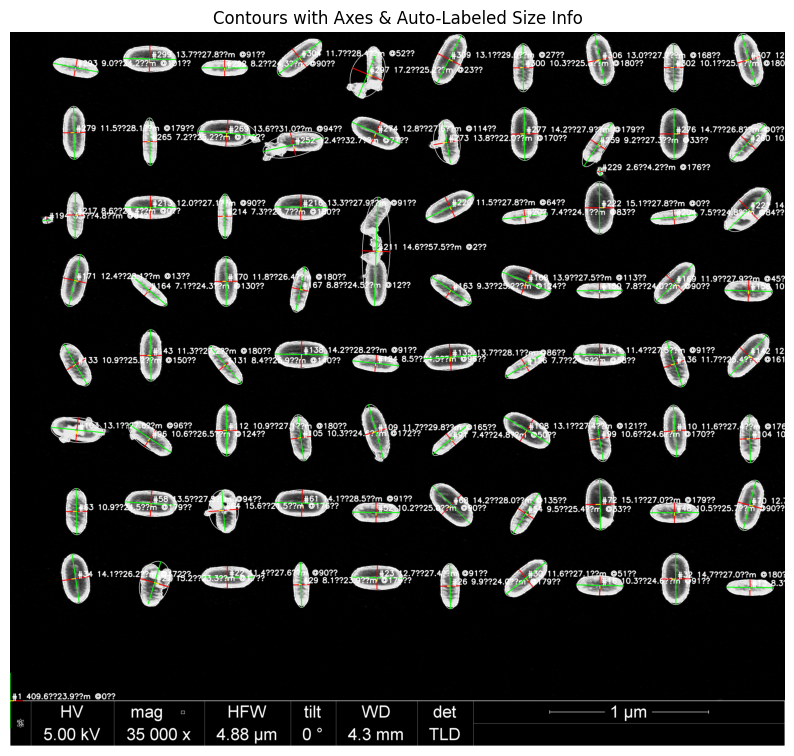

In [16]:
# %%
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# ================================================================
# 🧩 使用者設定
# ================================================================
path_img = r"c:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI"   # 改成你的資料夾
file_name = "2nd_dep_barc6s.tif"                      # 改成你的圖檔名稱
pixel_size = 0.1  # 單位：μm/pixel，可自行修改
font_scale = 1.3   # 字體放大倍率
font_thickness = 3 # 字體線寬

# ================================================================
# 🖼️ 讀取影像並做前處理
# ================================================================
img = cv2.imread(os.path.join(path_img, file_name))
if img is None:
    raise FileNotFoundError("❌ 找不到指定影像，請確認路徑與檔名")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ================================================================
# 🔍 找出輪廓
# ================================================================
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"找到 {len(contours)} 個圖形")

# ================================================================
# 📏 計算每個圖形資訊
# ================================================================
info_list = []
img_draw = img.copy()

# 記錄已放置的文字框區域，用來避免重疊
text_positions = []

def is_overlapping(x, y, text_positions, min_dist=40):
    for tx, ty in text_positions:
        if abs(x - tx) < min_dist and abs(y - ty) < min_dist:
            return True
    return False

for i, cnt in enumerate(contours):
    area_px = cv2.contourArea(cnt)
    if area_px < 10:
        continue

    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (major, minor), angle = ellipse
        major_um = major * pixel_size
        minor_um = minor * pixel_size
    else:
        x, y, w, h = cv2.boundingRect(cnt)
        major_um = max(w, h) * pixel_size
        minor_um = min(w, h) * pixel_size
        angle = 0

    info_list.append({
        "id": i+1,
        "center": (x, y),
        "major": major_um,
        "minor": minor_um,
        "angle": angle
    })

    # === 顏色設定 ===
    color_long = (0, 0, 255)      # 🔴 長軸
    color_short = (0, 255, 0)     # 🟢 短軸
    color_angle = (0, 255, 255)   # 🟡 角度線

    # === 繪製輪廓與橢圓 ===
    cv2.drawContours(img_draw, [cnt], -1, (255, 255, 255), 2)
    if len(cnt) >= 5:
        cv2.ellipse(img_draw, ellipse, (255, 255, 255), 2)

    # === 中心點 ===
    cv2.circle(img_draw, (int(x), int(y)), 7, (255, 0, 0), -1)

    # === 長軸/短軸線 ===
    angle_rad = math.radians(angle)
    major_axis_x = (major / 2) * math.cos(angle_rad)
    major_axis_y = (major / 2) * math.sin(angle_rad)
    minor_axis_x = (minor / 2) * math.cos(angle_rad + math.pi/2)
    minor_axis_y = (minor / 2) * math.sin(angle_rad + math.pi/2)

    # 長軸線 (紅)
    pt1_long = (int(x - major_axis_x), int(y - major_axis_y))
    pt2_long = (int(x + major_axis_x), int(y + major_axis_y))
    cv2.line(img_draw, pt1_long, pt2_long, color_long, 4)

    # 短軸線 (綠)
    pt1_short = (int(x - minor_axis_x), int(y - minor_axis_y))
    pt2_short = (int(x + minor_axis_x), int(y + minor_axis_y))
    cv2.line(img_draw, pt1_short, pt2_short, color_short, 4)

    # 角度線（黃） — 從中心延伸出一小段角度方向
    end_angle = (int(x + 0.3 * major_axis_x), int(y + 0.3 * major_axis_y))
    cv2.line(img_draw, (int(x), int(y)), end_angle, color_angle, 3)

    # === 文字標註（自動避開重疊） ===
    label = f"#{i+1} {major_um:.1f}×{minor_um:.1f}µm @{angle:.0f}°"
    tx, ty = int(x) + 10, int(y) - 10
    offset = 0
    while is_overlapping(tx, ty + offset, text_positions, min_dist=40):
        offset += 20
    ty += offset
    text_positions.append((tx, ty))

    cv2.putText(img_draw, label, (tx, ty),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255,255,255), font_thickness, cv2.LINE_AA)

# ================================================================
# 🧾 列印結果
# ================================================================
print("\n=== 測量結果 (μm) ===")
for obj in info_list:
    print(f"圖形#{obj['id']}: 長軸={obj['major']:.2f} µm, 短軸={obj['minor']:.2f} µm, 角度={obj['angle']:.1f}°")

# ================================================================
# 🎨 顯示結果
# ================================================================
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Contours with Axes & Auto-Labeled Size Info")
plt.axis("off")
plt.show()


找到 7121 個圖形

✅ 圖片已輸出至：C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\SEM\LE_LAYER1_ADI\SEM\-3_0\output_results


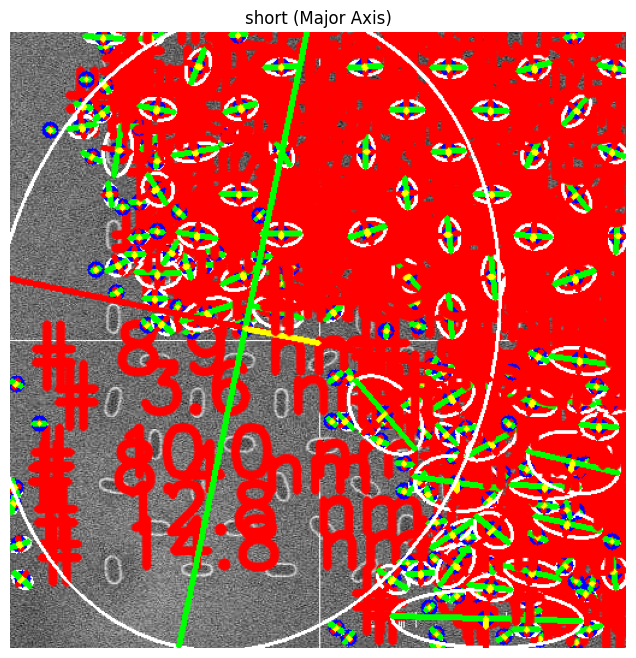

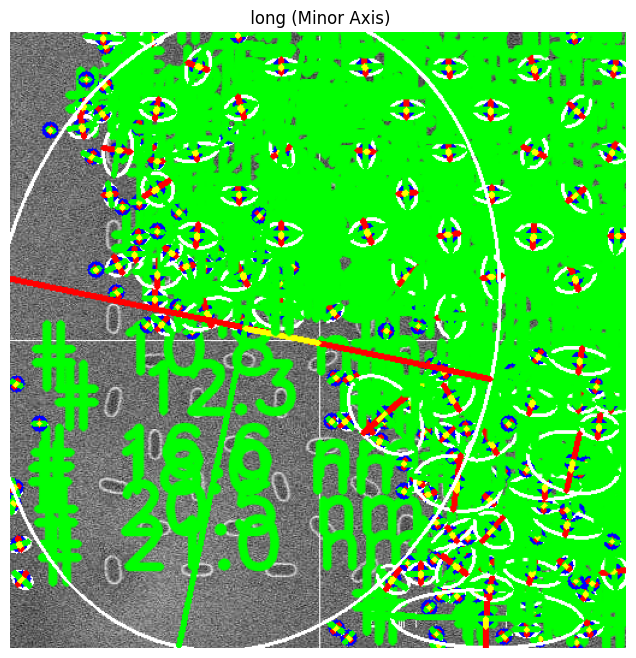

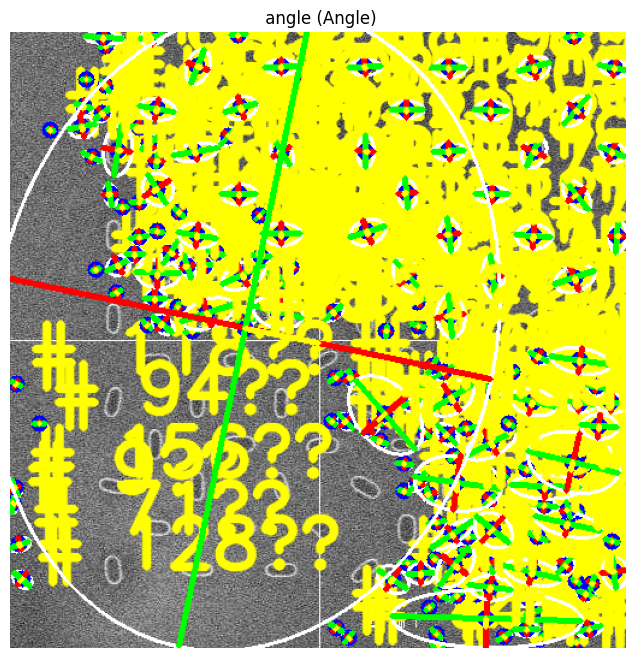

In [80]:
# %%
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# ================================================================
# 🧩 使用者設定
# ================================================================
path_img = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\SEM\LE_LAYER1_ADI\SEM\-3_0"   # 改成你的資料夾
file_name = "1014-p-lele1-LB0001.jpeg"                      # 改成你的圖檔名稱
pixel_size = 1.189  # 單位：μm/pixel
font_scale = 1.9
font_thickness = 5
save_output = True  # ✅ 是否輸出成檔案（True/False）

# ================================================================
# 🖼️ 讀取影像與前處理
# ================================================================
img = cv2.imread(os.path.join(path_img, file_name))
if img is None:
    raise FileNotFoundError("❌ 找不到指定影像，請確認路徑與檔名")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"找到 {len(contours)} 個圖形")

# ================================================================
# 📏 計算輪廓幾何資訊
# ================================================================
info_list = []
for i, cnt in enumerate(contours):
    area_px = cv2.contourArea(cnt)
    if area_px < 10:
        continue
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (major, minor), angle = ellipse
        major_um = major * pixel_size
        minor_um = minor * pixel_size
    else:
        x, y, w, h = cv2.boundingRect(cnt)
        major_um = max(w, h) * pixel_size
        minor_um = min(w, h) * pixel_size
        angle = 0
        ellipse = ((x+w/2, y+h/2), (w, h), 0)
    info_list.append({
        "id": i+1,
        "ellipse": ellipse,
        "center": (x, y),
        "major": major_um,
        "minor": minor_um,
        "angle": angle
    })

# ================================================================
# 🎨 繪圖函數
# ================================================================
def draw_with_label(img_base, info_list, label_type="major"):
    img_draw = img_base.copy()
    for obj in info_list:
        (x, y), (major, minor), angle = obj["ellipse"]
        major_um = obj["major"]
        minor_um = obj["minor"]

        # === 顏色設定 ===
        color_long = (0, 0, 255)    # 🔴 長軸
        color_short = (0, 255, 0)   # 🟢 短軸
        color_angle = (0, 255, 255) # 🟡 角度線

        # === 繪製橢圓與中心 ===
        cv2.ellipse(img_draw, obj["ellipse"], (255, 255, 255), 2)
        cv2.circle(img_draw, (int(x), int(y)), 7, (255, 0, 0), -1)

        # === 長軸與短軸 ===
        angle_rad = math.radians(angle)
        major_axis_x = (major / 2) * math.cos(angle_rad)
        major_axis_y = (major / 2) * math.sin(angle_rad)
        minor_axis_x = (minor / 2) * math.cos(angle_rad + math.pi/2)
        minor_axis_y = (minor / 2) * math.sin(angle_rad + math.pi/2)
        cv2.line(img_draw, (int(x-major_axis_x), int(y-major_axis_y)), (int(x+major_axis_x), int(y+major_axis_y)), color_long, 3)
        cv2.line(img_draw, (int(x-minor_axis_x), int(y-minor_axis_y)), (int(x+minor_axis_x), int(y+minor_axis_y)), color_short, 3)
        cv2.line(img_draw, (int(x), int(y)), (int(x+0.3*major_axis_x), int(y+0.3*major_axis_y)), color_angle, 3)

        # === 根據類型顯示對應文字 ===
        if label_type == "major":
            text = f"# {major_um:.1f} nm"
            color_text = color_long
        elif label_type == "minor":
            text = f"# {minor_um:.1f} nm"
            color_text = color_short
        elif label_type == "angle":
            text = f"# {angle:.0f}°"#{obj['id']}
            color_text = color_angle

        cv2.putText(img_draw, text, (int(x)+10, int(y)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, color_text, font_thickness, cv2.LINE_AA)
    return img_draw

# ================================================================
# 🖼️ 分別繪製三張圖
# ================================================================
img_major = draw_with_label(img, info_list, label_type="major")
img_minor = draw_with_label(img, info_list, label_type="minor")
img_angle = draw_with_label(img, info_list, label_type="angle")

# ================================================================
# 💾 輸出圖檔（可選）
# ================================================================
if save_output:
    out_dir = os.path.join(path_img, "output_results")
    os.makedirs(out_dir, exist_ok=True)
    cv2.imwrite(os.path.join(out_dir, "result_major.png"), img_major)
    cv2.imwrite(os.path.join(out_dir, "result_minor.png"), img_minor)
    cv2.imwrite(os.path.join(out_dir, "result_angle.png"), img_angle)
    print(f"\n✅ 圖片已輸出至：{out_dir}")

# ================================================================
# 🎨 分開顯示三張圖
# ================================================================
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_major, cv2.COLOR_BGR2RGB))
plt.title("short (Major Axis)")#🔴
plt.axis("off")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_minor, cv2.COLOR_BGR2RGB))
plt.title(" long (Minor Axis)")#🟢
plt.axis("off")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_angle, cv2.COLOR_BGR2RGB))
plt.title(" angle (Angle)")#🟡
plt.axis("off")
plt.show()


## 正式版

In [ ]:
# %%
import cv2
import numpy as np
import os

# ================================================================
# 🧩 使用者設定
# ================================================================
path_img = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\SEM\LE_LAYER1_ADI\SEM\-3_0"  # 改成你的資料夾
file_name = "1014-p-lele1-LB0001.jpeg"  # 改成你的圖檔名稱
save_output = True  # ✅ 是否輸出最終二值化結果

# ================================================================
# 🖼️ 讀取影像
# ================================================================
img = cv2.imread(os.path.join(path_img, file_name))
if img is None:
    raise FileNotFoundError("❌ 找不到指定影像，請確認路徑與檔名")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 3)  # 去除雜訊

# ================================================================
# 🎛️ 建立滑桿介面
# ================================================================
def nothing(x):
    pass

cv2.namedWindow("Interactive Threshold", cv2.WINDOW_NORMAL)
cv2.createTrackbar("Threshold", "Interactive Threshold", 127, 255, nothing)
cv2.createTrackbar("Invert", "Interactive Threshold", 0, 1, nothing)

print("👉 使用滑桿調整閾值（Threshold），按下 's' 儲存 或 'q' 離開。")

while True:
    thresh_value = cv2.getTrackbarPos("Threshold", "Interactive Threshold")
    invert = cv2.getTrackbarPos("Invert", "Interactive Threshold")

    # 根據滑桿設定執行閾值化
    thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, binary = cv2.threshold(gray, thresh_value, 255, thresh_type)

    # 顯示結果
    cv2.imshow("Interactive Threshold", binary)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q"):  # 按 q 離開
        print("❌ 離開視窗，不儲存。")
        break
    elif key == ord("s"):  # 按 s 儲存結果
        out_dir = os.path.join(path_img, "output_results")
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, "binary_interactive.png")
        cv2.imwrite(out_path, binary)
        print(f"✅ 已儲存二值化結果至：{out_path}")
        break

cv2.destroyAllWindows()


👉 使用滑桿調整閾值（Threshold），按下 's' 儲存 或 'q' 離開。


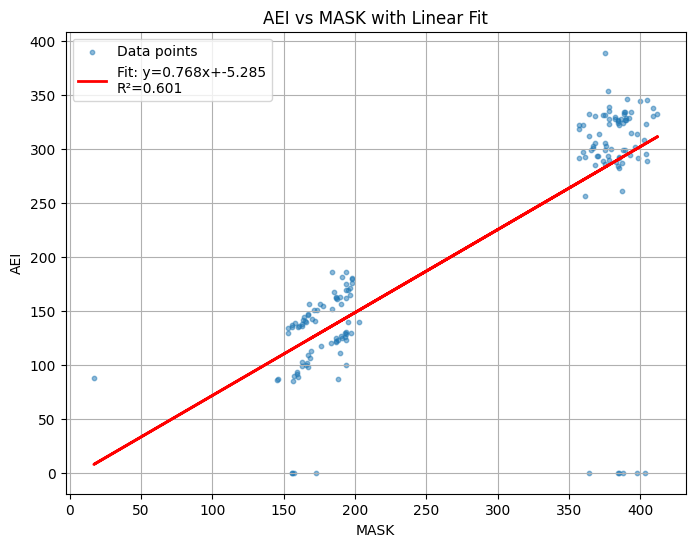

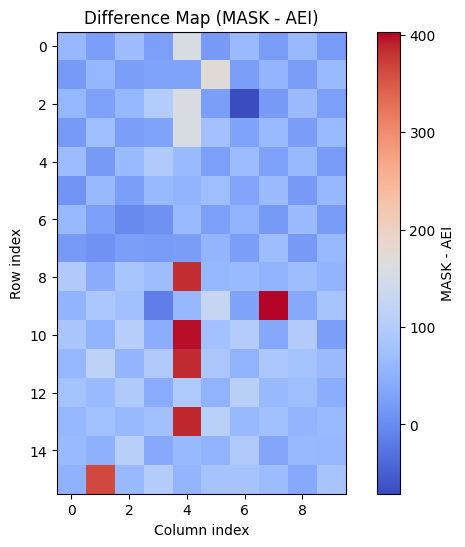

✅ 線性迴歸結果：y = 0.7679x + -5.2849, R² = 0.6008
✅ 差值矩陣尺寸：(16, 10)


In [38]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from pathlib import Path

# ================================================================
# 🧩 使用者設定
# ================================================================
path_AEI = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\AEI.csv"    # 改成 AEI 的路徑
path_MASK = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\Mask22.csv" # 改成 MASK 的路徑
save_fig = True                      # 是否儲存圖檔

# ================================================================
# 📖 讀取 CSV 檔案
# ================================================================
AEI = pd.read_csv(path_AEI, header=None, encoding='UTF-8').to_numpy()
MASK = pd.read_csv(path_MASK, header=None, encoding='UTF-8').to_numpy()


if AEI.shape != MASK.shape:
    raise ValueError(f"❌ AEI 與 MASK 尺寸不一致: {AEI.shape} vs {MASK.shape}")

# ================================================================
# 📊 1. AEI vs MASK 散點圖 + 線性迴歸
# ================================================================
X = MASK.flatten().reshape(-1, 1)
Y = AEI.flatten()

model = LinearRegression()
model.fit(X, Y)
Y_pred = model.predict(X)
r2 = r2_score(Y, Y_pred)

# 取得斜率與截距
slope = model.coef_[0]
intercept = model.intercept_

# 畫散點與回歸線
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, s=10, alpha=0.5, label="Data points")
plt.plot(X, Y_pred, color='red', linewidth=2, label=f"Fit: y={slope:.3f}x+{intercept:.3f}\nR²={r2:.3f}")
plt.xlabel("MASK")
plt.ylabel("AEI")
plt.title("AEI vs MASK with Linear Fit")
plt.legend()
plt.grid(True)
if save_fig:
    plt.savefig("AEI_vs_MASK_fit.png", dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# 🌈 2. 差值熱圖 (MASK - AEI)
# ================================================================
diff = MASK - AEI

plt.figure(figsize=(8, 6))
im = plt.imshow(diff, cmap='coolwarm', origin='upper')
plt.colorbar(im, label="MASK - AEI")
plt.title("Difference Map (MASK - AEI)")
plt.xlabel("Column index")
plt.ylabel("Row index")
if save_fig:
    plt.savefig("MASK_minus_AEI_map.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 線性迴歸結果：y = {slope:.4f}x + {intercept:.4f}, R² = {r2:.4f}")
print(f"✅ 差值矩陣尺寸：{diff.shape}")


In [42]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

# ================================================================
# 🧩 使用者設定（請改成你的檔案路徑）
# ================================================================
path_AEI   = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\AEI.csv"     # AEI 數值矩陣
path_MASK  = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\Mask22.csv"   # MASK 數值矩陣
path_LABEL = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\label.csv"  # L1/L2 標記矩陣（字串：L1 或 L2）

out_dir = Path("./output_L1L2_analysis")  # 輸出資料夾
out_dir.mkdir(parents=True, exist_ok=True)

save_fig = True   # 是否輸出圖檔

# ================================================================
# 📖 安全讀檔（自動嘗試常見編碼）
# ================================================================
def read_csv_matrix(path, header=None):
    encodings = ["utf-8-sig", "big5", "latin1"]
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, header=header, encoding=enc)
        except Exception as e:
            last_err = e
    raise last_err

AEI_df   = read_csv_matrix(path_AEI, header=None)
MASK_df  = read_csv_matrix(path_MASK, header=None)
LABEL_df = read_csv_matrix(path_LABEL, header=None)

AEI  = AEI_df.to_numpy()
MASK = MASK_df.to_numpy()
LABEL_raw = LABEL_df.astype(str).to_numpy()

# 尺寸檢查
if AEI.shape != MASK.shape or AEI.shape != LABEL_raw.shape:
    raise ValueError(f"❌ 尺寸不一致：AEI {AEI.shape}, MASK {MASK.shape}, LABEL {LABEL_raw.shape}")

# 正規化標籤字串
LABEL = np.char.upper(np.char.strip(LABEL_raw.astype(str)))

# ================================================================
# 🚫 移除 AEI == 1 的資料點
# ================================================================
mask_valid = (AEI != 0)
# 對 AEI, MASK, LABEL 同時過濾
AEI = np.where(mask_valid, AEI, np.nan)
MASK = np.where(mask_valid, MASK, np.nan)
LABEL_raw = np.where(mask_valid, LABEL_raw, np.nan)

# ================================================================
# 🌈 差值矩陣（整體）
# ================================================================
diff = MASK - AEI

# ================================================================
# 🗂️ 依標籤拆分資料：建立 L1 / L2 的表格（含座標）
# ================================================================
rows, cols = AEI.shape
rr, cc = np.indices((rows, cols))

def build_df_for_label(lbl):
    sel = (LABEL == lbl)
    data = {
        "row": rr[sel],
        "col": cc[sel],
        "MASK": MASK[sel].astype(float),
        "AEI":  AEI[sel].astype(float),
        "DIFF": (MASK[sel] - AEI[sel]).astype(float),
    }
    return pd.DataFrame(data)

df_L1 = build_df_for_label("L1")
df_L2 = build_df_for_label("L2")

# 儲存各自 CSV（欄位：row, col, MASK, AEI, DIFF）
df_L1.to_csv(out_dir / "L1_data.csv", index=False, encoding="utf-8-sig")
df_L2.to_csv(out_dir / "L2_data.csv", index=False, encoding="utf-8-sig")

print(f"✅ 已輸出：{out_dir/'L1_data.csv'}")
print(f"✅ 已輸出：{out_dir/'L2_data.csv'}")

# ================================================================
# 📈 線性回歸 + 誤差統計（函式）
# ================================================================
def fit_and_metrics(df, label_name="Lx"):
    if len(df) == 0:
        return None
    X = df["MASK"].to_numpy().reshape(-1, 1)
    Y = df["AEI"].to_numpy()
    model = LinearRegression()
    model.fit(X, Y)
    Y_pred = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(Y, Y_pred)

    err = df["DIFF"].to_numpy()       # MASK - AEI
    mae = mean_absolute_error(np.zeros_like(err), err)  # 等價於 |err| 的平均
    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    bias = np.mean(err)               # 平均誤差（正：MASK偏大）

    # MAPE（若數值可能為0，避免除零）
    eps = 1e-12
    mape = np.mean(np.abs(err) / (np.abs(df["AEI"].to_numpy()) + eps)) * 100.0

    metrics = {
        "label": label_name,
        "n": len(df),
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "bias": bias,
        "mae": mae,
        "rmse": rmse,
        "mape_%": mape
    }
    return model, metrics

res_L1 = fit_and_metrics(df_L1, "L1")
res_L2 = fit_and_metrics(df_L2, "L2")

# 輸出指標
def print_metrics(m):
    if m is None:
        print("（無資料）"); return
    print(f"[{m['label']}] n={m['n']}")
    print(f"  y = {m['slope']:.6f} x + {m['intercept']:.6f}  |  R²={m['r2']:.6f}")
    print(f"  bias={m['bias']:.6f} , MAE={m['mae']:.6f} , RMSE={m['rmse']:.6f} , MAPE={m['mape_%']:.3f}%")

print_metrics(res_L1[1] if res_L1 else None)
print_metrics(res_L2[1] if res_L2 else None)

# 另存彙總成 CSV
summary_rows = []
if res_L1: summary_rows.append(res_L1[1])
if res_L2: summary_rows.append(res_L2[1])
pd.DataFrame(summary_rows).to_csv(out_dir / "fit_summary_L1L2.csv", index=False, encoding="utf-8-sig")
print(f"✅ 已輸出：{out_dir/'fit_summary_L1L2.csv'}")

# ================================================================
# 📊 圖：散點 + 線性回歸線（L1 / L2 分開顯示）
# ================================================================
plt.figure(figsize=(8, 6))

if len(df_L1):
    X1 = df_L1["MASK"].to_numpy().reshape(-1, 1)
    Y1 = df_L1["AEI"].to_numpy()
    plt.scatter(X1, Y1, s=10, alpha=0.5, label=f"L1 (n={len(df_L1)})")
    # 畫回歸線（使用排序後的 X，讓線條連續）
    if res_L1:
        order = np.argsort(X1[:,0])
        X1s = X1[order]
        Y1p = res_L1[0].predict(X1s)
        plt.plot(X1s, Y1p, linewidth=2, label=f"L1 fit: y={res_L1[1]['slope']:.3f}x+{res_L1[1]['intercept']:.3f} (R²={res_L1[1]['r2']:.3f})")

if len(df_L2):
    X2 = df_L2["MASK"].to_numpy().reshape(-1, 1)
    Y2 = df_L2["AEI"].to_numpy()
    plt.scatter(X2, Y2, s=10, alpha=0.5, label=f"L2 (n={len(df_L2)})")
    if res_L2:
        order = np.argsort(X2[:,0])
        X2s = X2[order]
        Y2p = res_L2[0].predict(X2s)
        plt.plot(X2s, Y2p, linewidth=2, label=f"L2 fit: y={res_L2[1]['slope']:.3f}x+{res_L2[1]['intercept']:.3f} (R²={res_L2[1]['r2']:.3f})")

plt.xlabel("MASK")
plt.ylabel("AEI")
plt.title("AEI vs MASK – L1/L2 分組與線性回歸")
plt.grid(True, alpha=0.3)
plt.legend()
if save_fig:
    plt.savefig(out_dir / "AEI_vs_MASK_L1L2_fit.png", dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# 🌡️ 圖：2D 差值熱圖（整體 & L1/L2 遮罩）
# ================================================================
plt.figure(figsize=(7, 6))
im = plt.imshow(diff, cmap="coolwarm", origin="upper")
plt.colorbar(im, label="MASK - AEI")
plt.title("Difference Map (MASK - AEI)")
plt.xlabel("Column index")
plt.ylabel("Row index")
if save_fig:
    plt.savefig(out_dir / "diff_map_all.png", dpi=300, bbox_inches='tight')
plt.show()

# L1 位置的 diff（非 L1 設為 NaN 以便 colormap 只顯示 L1）
L1_mask = (LABEL == "L1")
L2_mask = (LABEL == "L2")
diff_L1 = np.full_like(diff, np.nan, dtype=float)
diff_L2 = np.full_like(diff, np.nan, dtype=float)
diff_L1[L1_mask] = diff[L1_mask]
diff_L2[L2_mask] = diff[L2_mask]

plt.figure(figsize=(7, 6))
im1 = plt.imshow(diff_L1, cmap="coolwarm", origin="upper")
plt.colorbar(im1, label="MASK - AEI (L1 only)")
plt.title("Difference Map – L1 only")
plt.xlabel("Column index"); plt.ylabel("Row index")
if save_fig:
    plt.savefig(out_dir / "diff_map_L1.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 6))
im2 = plt.imshow(diff_L2, cmap="coolwarm", origin="upper")
plt.colorbar(im2, label="MASK - AEI (L2 only)")
plt.title("Difference Map – L2 only")
plt.xlabel("Column index"); plt.ylabel("Row index")
if save_fig:
    plt.savefig(out_dir / "diff_map_L2.png", dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# 🧾 也把 L1/L2 的矩陣（0/1 mask）另存，以便後續運算
# ================================================================
pd.DataFrame(L1_mask.astype(int)).to_csv(out_dir / "L1_mask_matrix.csv", index=False, header=False, encoding="utf-8-sig")
pd.DataFrame(L2_mask.astype(int)).to_csv(out_dir / "L2_mask_matrix.csv", index=False, header=False, encoding="utf-8-sig")
print(f"✅ 已輸出：{out_dir/'L1_mask_matrix.csv'} , {out_dir/'L2_mask_matrix.csv'}")

print("🎉 完成：已分開 L1/L2 並輸出 CSV、回歸與誤差分析與熱圖。")


✅ 已輸出：output_L1L2_analysis\L1_data.csv
✅ 已輸出：output_L1L2_analysis\L2_data.csv


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

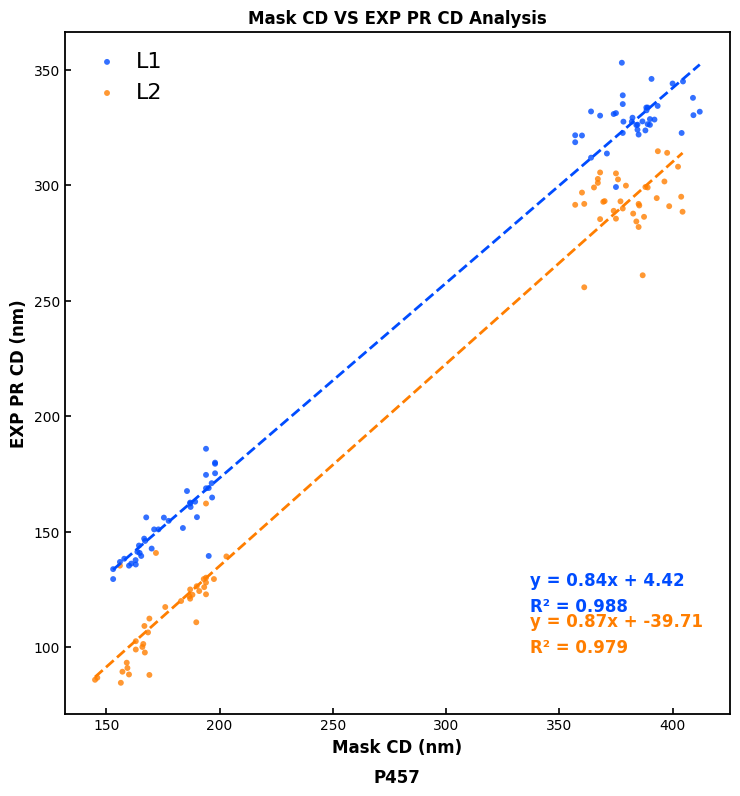

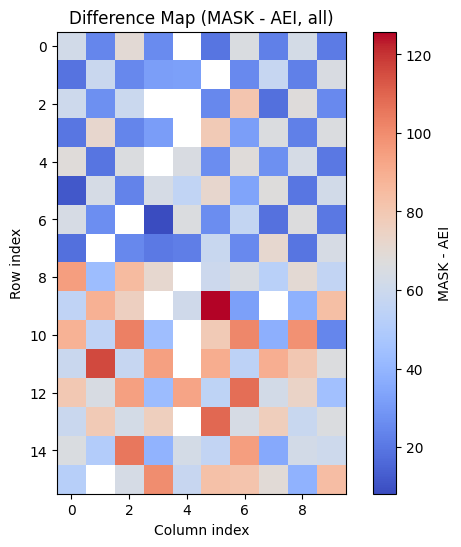

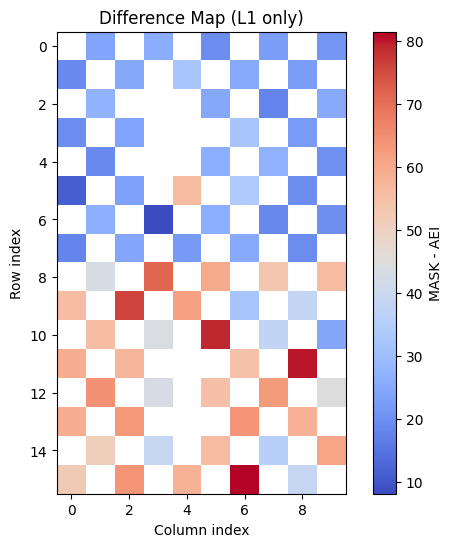

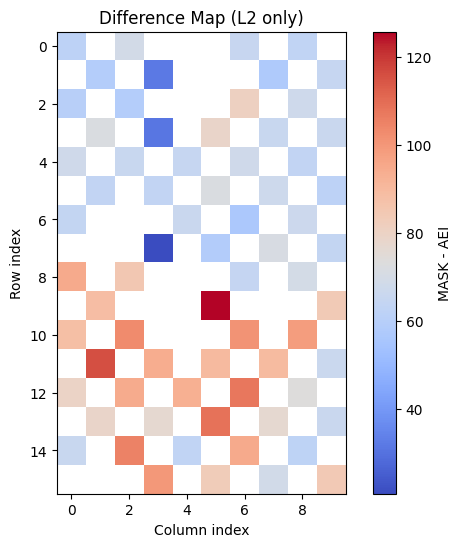

🎉 完成！AEI==0,1 已轉 NaN 並自動忽略，結果已輸出於 ./output_L1L2_analysis/


In [66]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

# ================================================================
# 🧩 使用者設定
# ================================================================
path_AEI   = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\AEI.csv"     # AEI 數值矩陣
path_MASK  = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\Mask22.csv"   # MASK 數值矩陣
path_LABEL = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\label.csv"  # L1/L2 標記矩陣（字串：L1 或 L2）

out_dir = Path("./output_L1L2_analysis")
out_dir.mkdir(parents=True, exist_ok=True)

save_fig = True

# ================================================================
# 📖 安全讀檔
# ================================================================
def read_csv_matrix(path, header=None):
    encodings = ["utf-8-sig", "big5", "latin1"]
    for enc in encodings:
        try:
            return pd.read_csv(path, header=header, encoding=enc)
        except Exception:
            continue
    raise ValueError(f"⚠️ 無法正確讀取 {path}")

AEI_df   = read_csv_matrix(path_AEI, header=None)
MASK_df  = read_csv_matrix(path_MASK, header=None)
LABEL_df = read_csv_matrix(path_LABEL, header=None)

AEI  = AEI_df.to_numpy()
MASK = MASK_df.to_numpy()
LABEL_raw = LABEL_df.astype(str).to_numpy()

if AEI.shape != MASK.shape or AEI.shape != LABEL_raw.shape:
    raise ValueError(f"❌ 尺寸不一致：AEI {AEI.shape}, MASK {MASK.shape}, LABEL {LABEL_raw.shape}")

# ================================================================
# 🚫 AEI == 0 或 AEI == 1 → 轉成 NaN
# ================================================================
AEI = np.where((AEI == 0) | (AEI == 1), np.nan, AEI)

# ================================================================
# 標籤正規化
# ================================================================
LABEL = np.char.upper(np.char.strip(LABEL_raw.astype(str)))

# ================================================================
# 📊 差值矩陣
# ================================================================
diff = MASK - AEI

rows, cols = AEI.shape
rr, cc = np.indices((rows, cols))

# ================================================================
# 🧱 建立 L1 / L2 DataFrame（自動略過 NaN）
# ================================================================
def build_df_for_label(lbl):
    sel = (LABEL == lbl)
    data = {
        "row": rr[sel],
        "col": cc[sel],
        "MASK": MASK[sel].astype(float),
        "AEI": AEI[sel].astype(float),
    }
    df = pd.DataFrame(data)
    df["DIFF"] = df["MASK"] - df["AEI"]
    df = df.dropna(subset=["MASK", "AEI", "DIFF"])  # 移除含 NaN
    return df

df_L1 = build_df_for_label("L1")
df_L2 = build_df_for_label("L2")

df_L1.to_csv(out_dir / "L1_data.csv", index=False, encoding="utf-8-sig")
df_L2.to_csv(out_dir / "L2_data.csv", index=False, encoding="utf-8-sig")

# ================================================================
# 📈 線性回歸 + 誤差統計
# ================================================================
def fit_and_metrics(df, label_name="Lx"):
    if len(df) == 0:
        print(f"⚠️ {label_name} 無有效資料")
        return None
    X = df["MASK"].to_numpy().reshape(-1, 1)
    Y = df["AEI"].to_numpy()
    model = LinearRegression().fit(X, Y)
    Y_pred = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(Y, Y_pred)
    err = df["DIFF"].to_numpy()

    metrics = {
        "label": label_name,
        "n": len(df),
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "bias": np.nanmean(err),
        "mae": np.nanmean(np.abs(err)),
        "rmse": np.sqrt(np.nanmean(err**2)),
        "mape_%": np.nanmean(np.abs(err / (Y + 1e-12))) * 100
    }
    return model, metrics

res_L1 = fit_and_metrics(df_L1, "L1")
res_L2 = fit_and_metrics(df_L2, "L2")

# ================================================================
# 📘 輸出結果總表
# ================================================================
summary_rows = []
if res_L1: summary_rows.append(res_L1[1])
if res_L2: summary_rows.append(res_L2[1])
pd.DataFrame(summary_rows).to_csv(out_dir / "fit_summary_L1L2.csv", index=False, encoding="utf-8-sig")

# ================================================================
# 📊 散點圖 + 回歸線
# ================================================================
# ================================================================
# 🎨 專業版：出版風格 Mask vs AEI CD 回歸圖
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7.5, 8))  # 調整比例接近範例

# === 自訂每組顏色 ===
configs = [
    (df_L1, res_L1, "#004CFF", "L1"),
    (df_L2, res_L2, "#FF7E00", "L2"),
]

# === 散點 + 回歸線 + 方程式文字 ===
text_y_offset = 0.06  # 控制方程式垂直間距
text_start_y = 0.15   # 初始文字位置（比例座標）

for i, (df, res, color, label_name) in enumerate(configs):
    if res is None or df is None or len(df) == 0:
        continue

    X = df["MASK"].to_numpy().reshape(-1, 1)
    Y = df["AEI"].to_numpy()

    # 散點
    plt.scatter(X, Y, s=18, alpha=0.8, label=label_name, color=color, edgecolor="none")

    # 回歸線
    Xs = np.linspace(np.nanmin(X), np.nanmax(X), 200).reshape(-1, 1)
    Ys = res[0].predict(Xs)
    plt.plot(Xs, Ys, color=color, linewidth=2.0, linestyle="--")

    # 方程式文字（對應顏色）
    slope = res[1]["slope"]
    intercept = res[1]["intercept"]
    r2 = res[1]["r2"]

    ypos = text_start_y - i * text_y_offset
    plt.text(
        0.7, ypos,
        f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r2:.3f}",
        transform=plt.gca().transAxes,
        color=color,
        fontsize=12,
        weight="bold",
        linespacing=1.6
    )

# === 軸與標題設定 ===
plt.xlabel("Mask CD (nm)", fontsize=12, weight="bold")
plt.ylabel("EXP PR CD (nm)", fontsize=12, weight="bold")
plt.title("Mask CD VS EXP PR CD Analysis", fontsize=12, weight="bold", pad=6)

plt.legend(frameon=False, fontsize=16, loc="upper left", handletextpad=0.3)
plt.text(0.5, -0.10, "P457", fontsize=12, weight="bold", ha="center", transform=plt.gca().transAxes)

# === 刻度樣式與邊框 ===
plt.tick_params(direction="in", length=4, width=1.2, labelsize=10)
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.3)

plt.grid(False)
plt.tight_layout()

# 儲存高解析圖
if save_fig:
    plt.savefig(out_dir / "AEI_vs_MASK_publication_style.png", dpi=600, bbox_inches="tight", transparent=False)

plt.show()


# ================================================================
# 🌈 差值熱圖
# ================================================================
def plot_diff_map(data, title, filename):
    plt.figure(figsize=(7,6))
    im = plt.imshow(data, cmap="coolwarm", origin="upper")
    plt.title(title)
    plt.colorbar(im, label="MASK - AEI")
    plt.xlabel("Column index")
    plt.ylabel("Row index")
    if save_fig:
        plt.savefig(out_dir / filename, dpi=300, bbox_inches='tight')
    plt.show()

L1_mask = (LABEL == "L1")
L2_mask = (LABEL == "L2")
diff_L1 = np.full_like(diff, np.nan, dtype=float)
diff_L2 = np.full_like(diff, np.nan, dtype=float)
diff_L1[L1_mask] = diff[L1_mask]
diff_L2[L2_mask] = diff[L2_mask]

plot_diff_map(diff, "Difference Map (MASK - AEI, all)", "diff_map_all.png")
plot_diff_map(diff_L1, "Difference Map (L1 only)", "diff_map_L1.png")
plot_diff_map(diff_L2, "Difference Map (L2 only)", "diff_map_L2.png")

print("🎉 完成！AEI==0,1 已轉 NaN 並自動忽略，結果已輸出於 ./output_L1L2_analysis/")


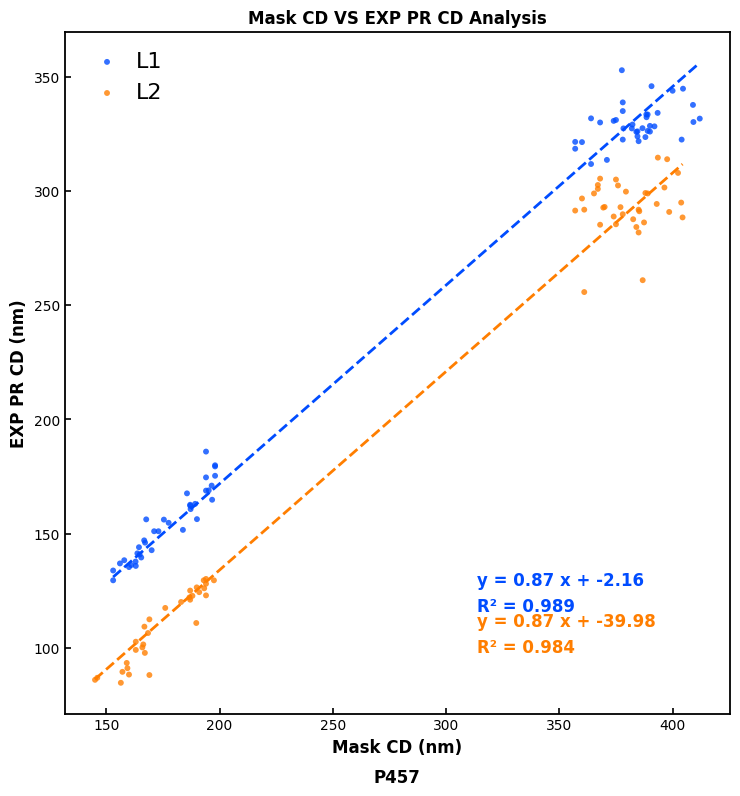

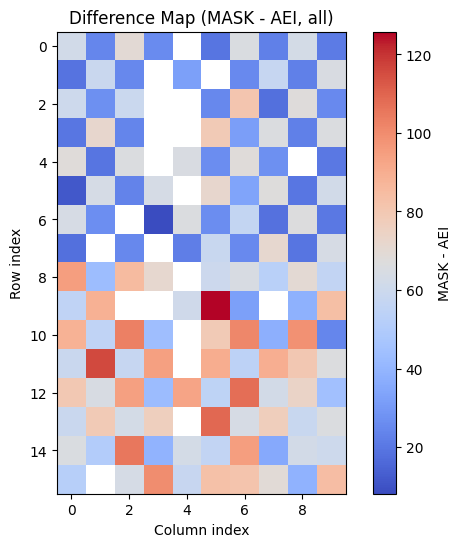

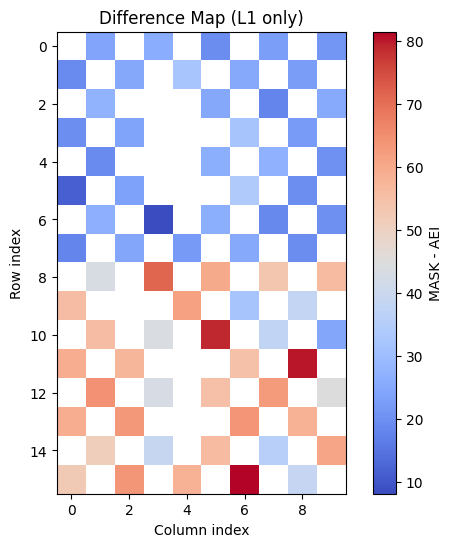

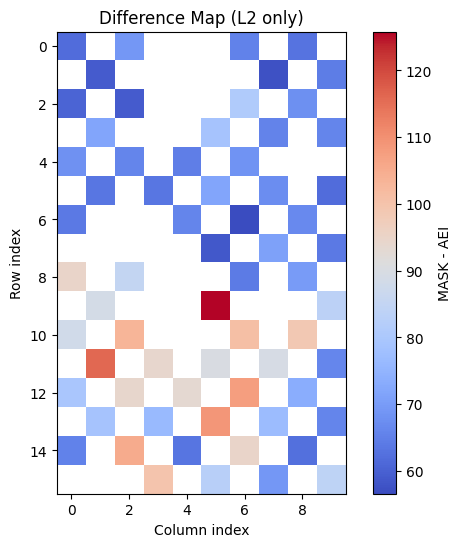

🎉 完成！AEI==0,1 已轉 NaN 並自動忽略，結果已輸出於 output_L1L2_analysis


In [78]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

# ================================================================
# 🧩 使用者設定
# ================================================================
path_AEI   = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\AEI.csv"     # AEI 數值矩陣
path_MASK  = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\Mask22.csv"  # MASK 數值矩陣
path_LABEL = r"C:\MADON_MASTER\NEWVIVO_PALLAB\ADIAEI\label.csv"   # L1/L2 標記矩陣

out_dir = Path("./output_L1L2_analysis")
out_dir.mkdir(parents=True, exist_ok=True)

save_fig = True

# ================================================================
# ⚙️ 模式設定：自由擬合 or 固定斜率
# ================================================================
fit_mode = "fixed"          # "free" 或 "fixed"
fixed_slope_value = 0.87    # 當 fit_mode="fixed" 時生效

# ================================================================
# 📖 安全讀檔
# ================================================================
def read_csv_matrix(path, header=None):
    encodings = ["utf-8-sig", "big5", "latin1"]
    for enc in encodings:
        try:
            return pd.read_csv(path, header=header, encoding=enc)
        except Exception:
            continue
    raise ValueError(f"⚠️ 無法正確讀取 {path}")

AEI_df   = read_csv_matrix(path_AEI, header=None)
MASK_df  = read_csv_matrix(path_MASK, header=None)
LABEL_df = read_csv_matrix(path_LABEL, header=None)

AEI  = AEI_df.to_numpy()
MASK = MASK_df.to_numpy()
LABEL_raw = LABEL_df.astype(str).to_numpy()

if AEI.shape != MASK.shape or AEI.shape != LABEL_raw.shape:
    raise ValueError(f"❌ 尺寸不一致：AEI {AEI.shape}, MASK {MASK.shape}, LABEL {LABEL_raw.shape}")

# ================================================================
# 🚫 AEI == 0 或 AEI == 1 → 轉成 NaN
# ================================================================
AEI = np.where((AEI == 0) | (AEI == 1), np.nan, AEI)

# ================================================================
# 標籤正規化
# ================================================================
LABEL = np.char.upper(np.char.strip(LABEL_raw.astype(str)))

# ================================================================
# 📊 差值矩陣
# ================================================================
diff = MASK - AEI
rows, cols = AEI.shape
rr, cc = np.indices((rows, cols))

# ================================================================
# 🧱 建立 L1 / L2 DataFrame（自動略過 NaN）
# ================================================================
def build_df_for_label(lbl):
    sel = (LABEL == lbl)
    data = {
        "row": rr[sel],
        "col": cc[sel],
        "MASK": MASK[sel].astype(float),
        "AEI": AEI[sel].astype(float),
    }
    df = pd.DataFrame(data)
    df["DIFF"] = df["MASK"] - df["AEI"]
    df = df.dropna(subset=["MASK", "AEI", "DIFF"])
    return df

df_L1 = build_df_for_label("L1")
df_L2 = build_df_for_label("L2")

df_L1.to_csv(out_dir / "L1_data.csv", index=False, encoding="utf-8-sig")
df_L2.to_csv(out_dir / "L2_data.csv", index=False, encoding="utf-8-sig")

# ================================================================
# 📈 線性回歸 + 誤差統計（加入固定斜率模式）
# ================================================================
def fit_and_metrics(df, label_name="Lx", mode="free", fixed_slope=None):
    if len(df) == 0:
        print(f"⚠️ {label_name} 無有效資料")
        return None
    X = df["MASK"].to_numpy().reshape(-1, 1)
    Y = df["AEI"].to_numpy()

    # 固定斜率模式
    if mode == "fixed" and fixed_slope is not None:
        slope = fixed_slope
        intercept = np.nanmean(Y - slope * X.flatten())
        Y_pred = slope * X.flatten() + intercept
        r2 = r2_score(Y, Y_pred)
    else:
        model = LinearRegression().fit(X, Y)
        slope = model.coef_[0]
        intercept = model.intercept_
        Y_pred = model.predict(X)
        r2 = r2_score(Y, Y_pred)

    err = df["DIFF"].to_numpy()
    metrics = {
        "label": label_name,
        "n": len(df),
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "bias": np.nanmean(err),
        "mae": np.nanmean(np.abs(err)),
        "rmse": np.sqrt(np.nanmean(err**2)),
        "mape_%": np.nanmean(np.abs(err / (Y + 1e-12))) * 100,
    }
    return (slope, intercept, r2, metrics)

res_L1 = fit_and_metrics(df_L1, "L1", fit_mode, fixed_slope_value)
res_L2 = fit_and_metrics(df_L2, "L2", fit_mode, fixed_slope_value)

# ================================================================
# 📘 輸出結果總表
# ================================================================
summary_rows = []
if res_L1: summary_rows.append(res_L1[3])
if res_L2: summary_rows.append(res_L2[3])
pd.DataFrame(summary_rows).to_csv(out_dir / "fit_summary_L1L2.csv", index=False, encoding="utf-8-sig")

# ================================================================
# 📊 散點圖 + 回歸線（出版風格）
# ================================================================
plt.figure(figsize=(7.5, 8))
configs = [
    (df_L1, res_L1, "#004CFF", "L1"),
    (df_L2, res_L2, "#FF7E00", "L2"),
]

text_y_offset = 0.06
text_start_y = 0.15

for i, (df, res, color, label_name) in enumerate(configs):
    if res is None or df is None or len(df) == 0:
        continue

    slope, intercept, r2, metrics = res
    X = df["MASK"].to_numpy().reshape(-1, 1)
    Y = df["AEI"].to_numpy()

    plt.scatter(X, Y, s=18, alpha=0.8, label=label_name, color=color, edgecolor="none")

    Xs = np.linspace(np.nanmin(X), np.nanmax(X), 200)
    Ys = slope * Xs + intercept
    plt.plot(Xs, Ys, color=color, linewidth=2.0, linestyle="--")

    ypos = text_start_y - i * text_y_offset
    slope_label = f"{slope:.2f}" if fit_mode == "free" else f"{fixed_slope_value:.2f} "
    plt.text(
        0.62, ypos,
        f"y = {slope_label}x + {intercept:.2f}\nR² = {r2:.3f}",
        transform=plt.gca().transAxes,
        color=color,
        fontsize=12,
        weight="bold",
        linespacing=1.6
    )

plt.xlabel("Mask CD (nm)", fontsize=12, weight="bold")
plt.ylabel("EXP PR CD (nm)", fontsize=12, weight="bold")
plt.title("Mask CD VS EXP PR CD Analysis", fontsize=12, weight="bold", pad=6)

plt.legend(frameon=False, fontsize=16, loc="upper left", handletextpad=0.3)
plt.text(0.5, -0.10, "P457", fontsize=12, weight="bold", ha="center", transform=plt.gca().transAxes)

plt.tick_params(direction="in", length=4, width=1.2, labelsize=10)
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.3)

plt.grid(False)
plt.tight_layout()

if save_fig:
    plt.savefig(out_dir / f"AEI_vs_MASK_fit_{fit_mode}.png", dpi=600, bbox_inches="tight", transparent=False)

plt.show()

# ================================================================
# 🌈 差值熱圖
# ================================================================
def plot_diff_map(data, title, filename):
    plt.figure(figsize=(7,6))
    im = plt.imshow(data, cmap="coolwarm", origin="upper")
    plt.title(title)
    plt.colorbar(im, label="MASK - AEI")
    plt.xlabel("Column index")
    plt.ylabel("Row index")
    if save_fig:
        plt.savefig(out_dir / filename, dpi=300, bbox_inches='tight')
    plt.show()

L1_mask = (LABEL == "L1")
L2_mask = (LABEL == "L2")
diff_L1 = np.full_like(diff, np.nan, dtype=float)
diff_L2 = np.full_like(diff, np.nan, dtype=float)
diff_L1[L1_mask] = diff[L1_mask]
diff_L2[L2_mask] = diff[L2_mask]

plot_diff_map(diff, "Difference Map (MASK - AEI, all)", "diff_map_all.png")
plot_diff_map(diff_L1, "Difference Map (L1 only)", "diff_map_L1.png")
plot_diff_map(diff_L2, "Difference Map (L2 only)", "diff_map_L2.png")

print(f"🎉 完成！AEI==0,1 已轉 NaN 並自動忽略，結果已輸出於 {out_dir}")
